In [1]:
# ==============================================================================
# CELL 0: VISUAL HYGIENE PROTOCOL (SILENCE WARNINGS)
# ==============================================================================
import warnings

# 1. Suppress FutureWarnings (The most common offender in Pandas/Seaborn)
warnings.simplefilter(action='ignore', category=FutureWarning)

# 2. Suppress UserWarnings (Optional, use with caution, good for cleaner plots)
warnings.simplefilter(action='ignore', category=UserWarning)

# 3. Specific Pandas Setting to avoid "SettingWithCopy" noise if needed
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'

print("✅ Visual Hygiene Protocol Active: Warnings Silenced.")

✅ Visual Hygiene Protocol Active: Warnings Silenced.


In [2]:
# ==============================================================================
# CELL 1: PROJECT BOOTSTRAP - SETUP & IMPORTS
# ==============================================================================
# Author: _Pienza, ex_machina
# Purpose: This cell mounts Google Drive, imports all necessary libraries for
#          the Phase I EDA campaign, and establishes a connection to the
#          opus.db, ensuring the analytical environment is ready.
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. CORE LIBRARY IMPORTS
# ------------------------------------------------------------------------------
print("⏳ Importing core libraries...")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
print("✅ Core libraries imported successfully.")

# ------------------------------------------------------------------------------
# 2. MOUNT GOOGLE DRIVE
# ------------------------------------------------------------------------------
# This command will prompt for authorization to access your Google Drive.
print("\n⏳ Mounting Google Drive...")
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully.")
except Exception as e:
    print(f"🔴 ERROR: Failed to mount Google Drive. Details: {e}")
    # Halt execution if mounting fails
    raise

# ------------------------------------------------------------------------------
# 3. DATABASE CONNECTION SETUP
# ------------------------------------------------------------------------------
print("\n⏳ Establishing database connection...")

# Define the canonical path to the database file.
# This is the single source of truth for the database location.
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db' # Confirmed path

# Sanity Check: Verify that the database file actually exists at the path.
if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL ERROR: Database file not found at the specified path.")
    print(f"   -> Expected Path: {DB_PATH}")
    print(f"   Please verify the file path and ensure Google Drive is synced.")
    # Halt execution if the database file is missing
    raise FileNotFoundError("opus.db not found.")
else:
    print(f"✅ Database file found at: {DB_PATH}")

# Create the SQLAlchemy engine. This is the connection object we will reuse.
try:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ Database engine is ready.")
except Exception as e:
    print(f"🔴 ERROR: Failed to create database engine. Details: {e}")
    raise

# ------------------------------------------------------------------------------
# BOOTSTRAP COMPLETE
# ------------------------------------------------------------------------------
print("\n--- Environment is LIVE. Ready to proceed with EDA. ---")

⏳ Importing core libraries...
✅ Core libraries imported successfully.

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive mounted successfully.

⏳ Establishing database connection...
✅ Database file found at: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ Database engine is ready.

--- Environment is LIVE. Ready to proceed with EDA. ---


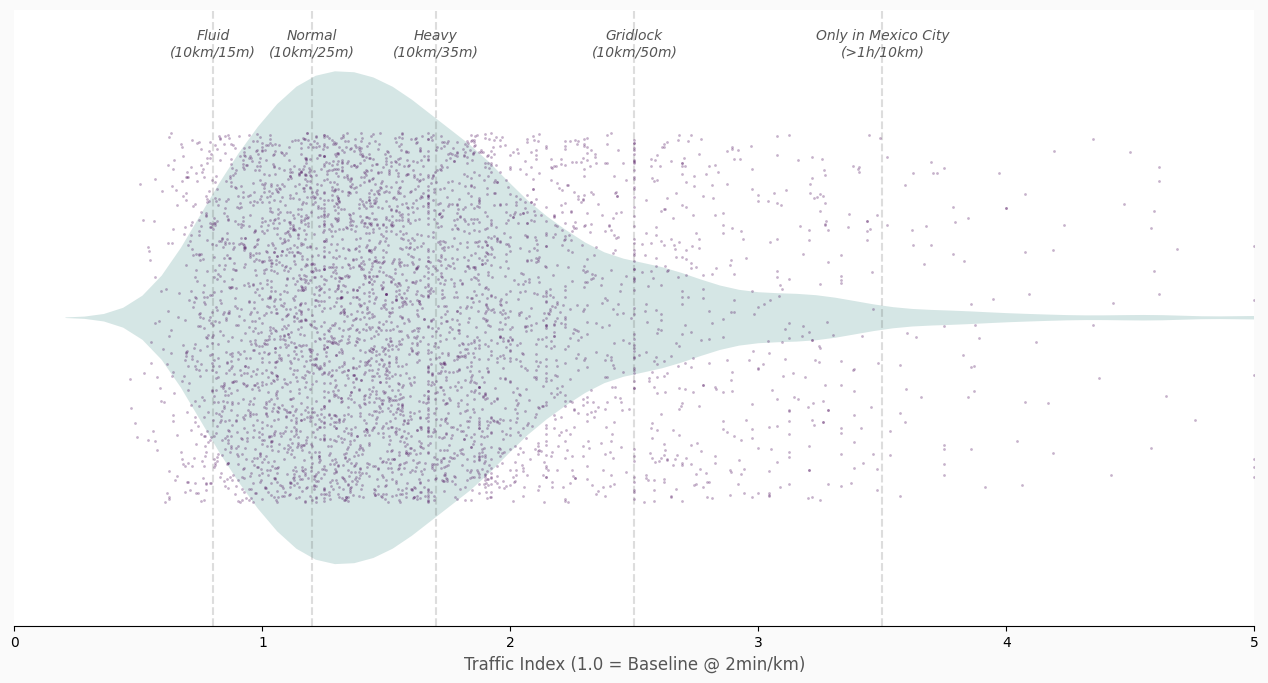

In [5]:
# ==============================================================================
# CELL 13 (REFACTORED): THE PHYSICS OF FRICTION (VEXATION INDEX)
# ==============================================================================
# Purpose: Deep univariate analysis of 'traffic_index_base_120'.
#          Transition from bars to density-based "Friction Manifolds".
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA CANONICAL PALETTE
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_GRAY = "#555555"

# 2. LOAD DATA & FILTER OUTLIERS
# The Traffic Index scales based on a 120s/km baseline[cite: 491, 538].
query = "SELECT traffic_index_base_120 FROM engineered_features WHERE traffic_index_base_120 IS NOT NULL"
df_traffic = pd.read_sql(query, db_engine)
df_traffic = df_traffic[df_traffic['traffic_index_base_120'] < 10]

# Categorization for labeling [cite: 538]
conditions = [
    (df_traffic['traffic_index_base_120'] < 1.0),
    (df_traffic['traffic_index_base_120'] < 1.5),
    (df_traffic['traffic_index_base_120'] < 2.0),
    (df_traffic['traffic_index_base_120'] >= 2.0)
]
choices = ['Fluid', 'Normal', 'Heavy', 'Gridlock']
df_traffic['label'] = np.select(conditions, choices, default='Solo en CDMX')

# 3. PLOTTING - THE FRICTION MANIFOLD
fig, ax = plt.subplots(figsize=(16, 8), facecolor='#FAFAFA')

# --- THE VIOLIN (The "Ghost" of Distribution) ---
sns.violinplot(
    data=df_traffic, x='traffic_index_base_120', color=PIENZA_TEAL,
    inner=None, alpha=0.2, ax=ax, linewidth=0
)

# --- THE STRIP (The "Particles" of Real Events) ---
# We use a jittered strip plot to show the ~4,700 events without bar-boringness.
sns.stripplot(
    data=df_traffic, x='traffic_index_base_120',
    color=PIENZA_PURPLE, alpha=0.3, size=2, jitter=0.3, ax=ax
)

# 4. ANNOTATIONS & REAL-WORLD ANCHORS [cite: 538]
# Logic: Anchoring the math to operational reality.
anchors = [
    (0.8, "Fluid\n(10km/15m)"),
    (1.2, "Normal\n(10km/25m)"),
    (1.7, "Heavy\n(10km/35m)"),
    (2.5, "Gridlock\n(10km/50m)"),
    (3.5, "Only in Mexico City\n(>1h/10km)")
]

for val, txt in anchors:
    ax.axvline(val, color=PIENZA_GRAY, alpha=0.2, linestyle='--')
    ax.text(val, ax.get_ylim()[1]*0.85, txt,
            ha='center', fontsize=10, color=PIENZA_GRAY, style='italic')

# Styling
ax.set_xlabel('Traffic Index (1.0 = Baseline @ 2min/km)', fontsize=12, color=PIENZA_GRAY)
ax.set_xlim(0, 5) # Focus on the most frequent operational range

sns.despine(left=True)
ax.set_yticks([]) # Clean UI: Remove Y axis as we are focusing on X density
plt.show()

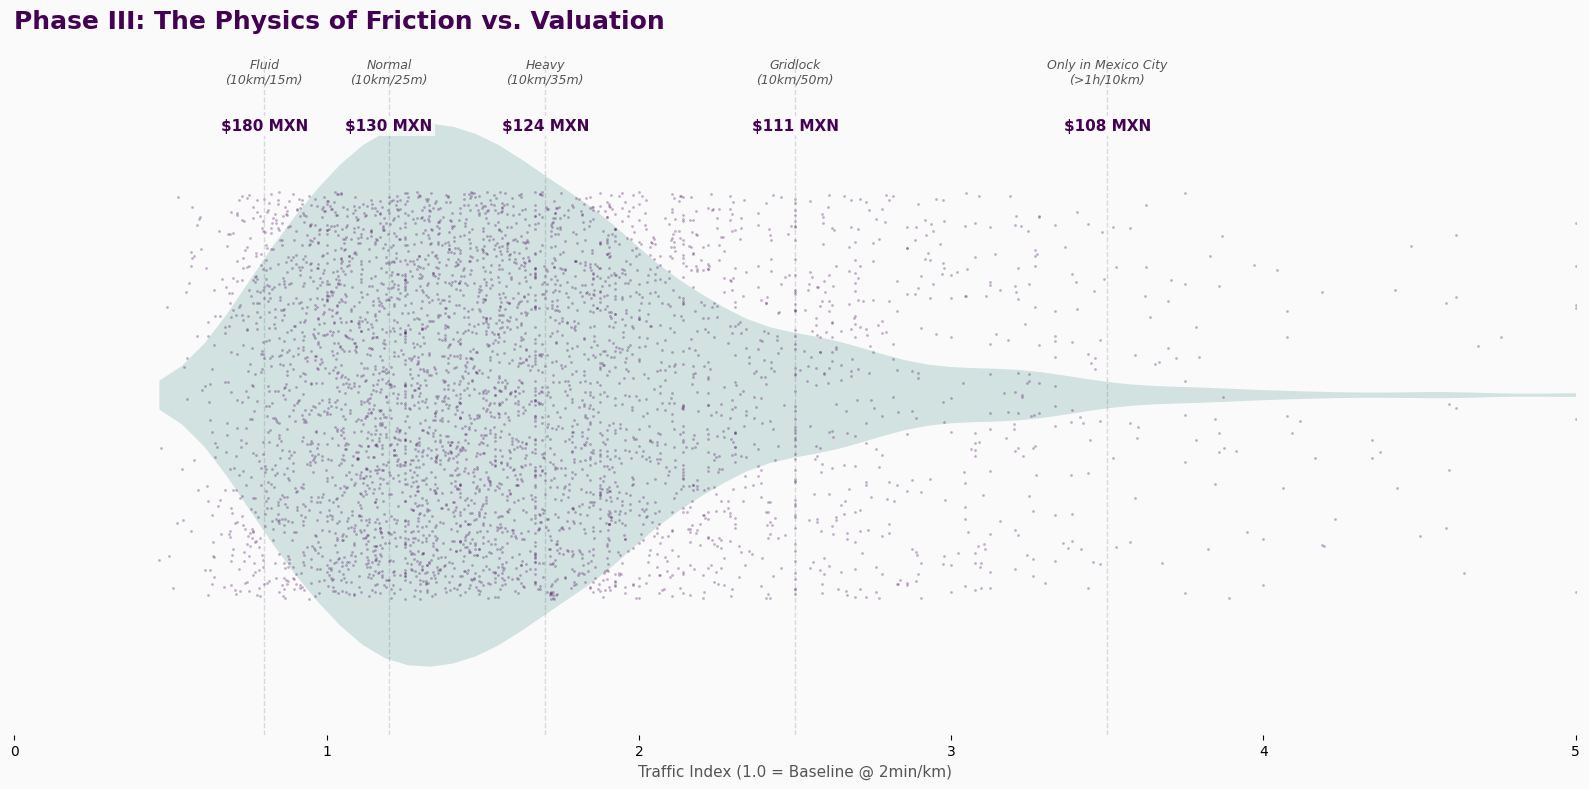

In [7]:
# ==============================================================================
# CELL 13 (CORRECTED): THE PHYSICS OF FRICTION (USING OFFICIAL VIEW)
# ==============================================================================
# Correction: Switched from manual JOIN to 'v_offers_human' view to resolve
#             missing column error. The view handles the relations internally.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA CANONICAL PALETTE
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_GRAY = "#555555"
PIENZA_BG = "#FAFAFA"

# 2. LOAD DATA FROM THE OFFICIAL EDA VIEW
# We query 'v_offers_human' which pre-joins offers + features
query = """
SELECT
    traffic_index_base_120,
    upfront_fare
FROM v_offers_human
WHERE traffic_index_base_120 IS NOT NULL
  AND traffic_index_base_120 < 10
"""
df_traffic = pd.read_sql(query, db_engine)

# 3. CALCULATE MEAN FARE PER TRAFFIC BIN (THE "TRANSPARENT BINS")
# Logic: We define the same traffic slices to calculate the average price per zone
bins = [0, 1.0, 1.5, 2.0, 3.0, 10]
labels = ['Fluid', 'Normal', 'Heavy', 'Gridlock', 'CDMX_Only']
df_traffic['traffic_bin'] = pd.cut(df_traffic['traffic_index_base_120'], bins=bins, labels=labels)

# Calculate the mean fare for each context (ignoring NaNs)
avg_fares = df_traffic.groupby('traffic_bin', observed=True)['upfront_fare'].mean().to_dict()

# 4. PLOTTING - THE FRICTION MANIFOLD
fig, ax = plt.subplots(figsize=(16, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# --- THE VIOLIN (The "Ghost" of Distribution) ---
sns.violinplot(
    data=df_traffic, x='traffic_index_base_120', color=PIENZA_TEAL,
    inner=None, alpha=0.2, ax=ax, linewidth=0, cut=0
)

# --- THE STRIP (The "Particles" of Real Events) ---
sns.stripplot(
    data=df_traffic, x='traffic_index_base_120',
    color=PIENZA_PURPLE, alpha=0.3, size=2, jitter=0.3, ax=ax, zorder=1
)

# 5. ANNOTATIONS: CONTEXT + FINANCIAL REALITY
# Anchors mapped to the Bin Logic [cite: 538]
anchors = [
    (0.8, "Fluid\n(10km/15m)", 'Fluid'),
    (1.2, "Normal\n(10km/25m)", 'Normal'),
    (1.7, "Heavy\n(10km/35m)", 'Heavy'),
    (2.5, "Gridlock\n(10km/50m)", 'Gridlock'),
    (3.5, "Only in Mexico City\n(>1h/10km)", 'CDMX_Only')
]

for x_val, label_text, bin_key in anchors:
    # 1. The Vertical Line (The Anchor)
    ax.axvline(x_val, color=PIENZA_GRAY, alpha=0.2, linestyle='--', linewidth=1)

    # 2. The Context Label (Top)
    ax.text(x_val, ax.get_ylim()[1]*0.92, label_text,
            ha='center', fontsize=9, color=PIENZA_GRAY, style='italic')

    # 3. THE "UBER COOL" METRIC: Average Fare for this density
    if bin_key in avg_fares:
        price = avg_fares[bin_key]
        ax.text(x_val, ax.get_ylim()[1]*0.78, f"${price:,.0f} MXN",
                ha='center', fontsize=11, weight='bold', color=PIENZA_PURPLE,
                bbox=dict(facecolor=PIENZA_BG, alpha=0.85, edgecolor='none', pad=2))

# Styling
ax.set_title('Phase III: The Physics of Friction vs. Valuation',
             fontsize=18, color=PIENZA_PURPLE, weight='bold', loc='left', pad=20)
ax.set_xlabel('Traffic Index (1.0 = Baseline @ 2min/km)', fontsize=11, color=PIENZA_GRAY)
ax.set_xlim(0, 5)

# Clean UI
sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')

plt.tight_layout()
plt.show()

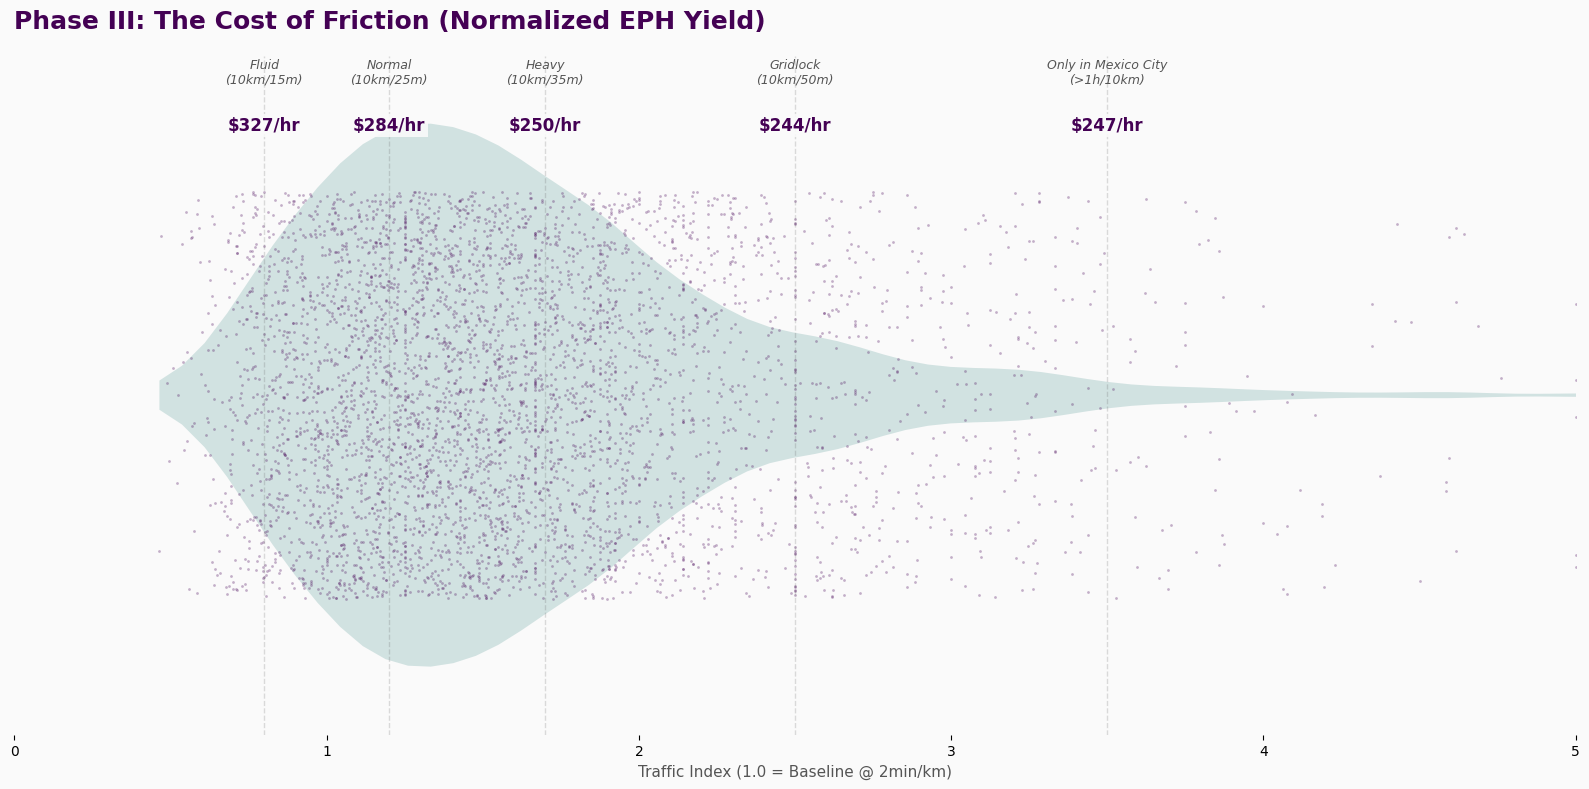

In [8]:
# ==============================================================================
# CELL 13 (REFACTORED - THE TRUTH SERUM): VEXATION VS. EPH (EFFICIENCY)
# ==============================================================================
# Purpose: The definitive correlation. Does Traffic Friction kill Hourly Yield?
#          Swapped 'Upfront Fare' (Absolute) for 'EPH Direct' (Normalized).
#          Using Median (Robust) instead of Mean (Noisy).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA CANONICAL PALETTE
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_GRAY = "#555555"
PIENZA_BG = "#FAFAFA"

# 2. LOAD DATA (THE NORMALIZED METRIC)
# We query 'eph_direct' (Earnings Per Hour) instead of raw fare.
# [cite_start]Schema: 'eph_direct' is in 'engineered_features' or 'v_offers_human' [cite: 524]
query = """
SELECT
    traffic_index_base_120,
    eph_direct
FROM v_offers_human
WHERE traffic_index_base_120 IS NOT NULL
  AND traffic_index_base_120 < 10
  AND eph_direct BETWEEN 0 AND 1000  -- Logical bounds to remove outliers
"""
df_traffic = pd.read_sql(query, db_engine)

# 3. CALCULATE ROBUST STATS PER TRAFFIC BIN
# We use the Median (50th percentile) as the Anchor, representing the "Typical Offer".
bins = [0, 1.0, 1.5, 2.0, 3.0, 10]
labels = ['Fluid', 'Normal', 'Heavy', 'Gridlock', 'CDMX_Only']
df_traffic['traffic_bin'] = pd.cut(df_traffic['traffic_index_base_120'], bins=bins, labels=labels)

# Group by bin and calculate Median EPH
median_eph = df_traffic.groupby('traffic_bin', observed=True)['eph_direct'].median().to_dict()

# 4. PLOTTING - THE EFFICIENCY CURVE
fig, ax = plt.subplots(figsize=(16, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# --- THE VIOLIN (The Shape of Friction) ---
sns.violinplot(
    data=df_traffic, x='traffic_index_base_120', color=PIENZA_TEAL,
    inner=None, alpha=0.2, ax=ax, linewidth=0, cut=0
)

# --- THE STRIP (The Reality of Offers) ---
sns.stripplot(
    data=df_traffic, x='traffic_index_base_120',
    color=PIENZA_PURPLE, alpha=0.3, size=2, jitter=0.3, ax=ax, zorder=1
)

# 5. ANNOTATIONS: THE "TRUTH" LABELS
anchors = [
    (0.8, "Fluid\n(10km/15m)", 'Fluid'),
    (1.2, "Normal\n(10km/25m)", 'Normal'),
    (1.7, "Heavy\n(10km/35m)", 'Heavy'),
    (2.5, "Gridlock\n(10km/50m)", 'Gridlock'),
    (3.5, "Only in Mexico City\n(>1h/10km)", 'CDMX_Only')
]

for x_val, label_text, bin_key in anchors:
    # Anchor Line
    ax.axvline(x_val, color=PIENZA_GRAY, alpha=0.2, linestyle='--', linewidth=1)

    # Context Label
    ax.text(x_val, ax.get_ylim()[1]*0.92, label_text,
            ha='center', fontsize=9, color=PIENZA_GRAY, style='italic')

    # THE HERO METRIC: Median EPH
    if bin_key in median_eph:
        price = median_eph[bin_key]
        # Logic: If EPH drops as traffic rises, we show it in RED/PURPLE.
        # If it holds steady, it's neutral.
        ax.text(x_val, ax.get_ylim()[1]*0.78, f"${price:,.0f}/hr",
                ha='center', fontsize=12, weight='bold', color=PIENZA_PURPLE,
                bbox=dict(facecolor=PIENZA_BG, alpha=0.9, edgecolor='none', pad=2))

# Styling
ax.set_title('Phase III: The Cost of Friction (Normalized EPH Yield)',
             fontsize=18, color=PIENZA_PURPLE, weight='bold', loc='left', pad=20)
ax.set_xlabel('Traffic Index (1.0 = Baseline @ 2min/km)', fontsize=11, color=PIENZA_GRAY)
ax.set_xlim(0, 5)

# Remove Y Axis (We are analyzing X-density vs implied EPH)
sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')

plt.tight_layout()
plt.show()

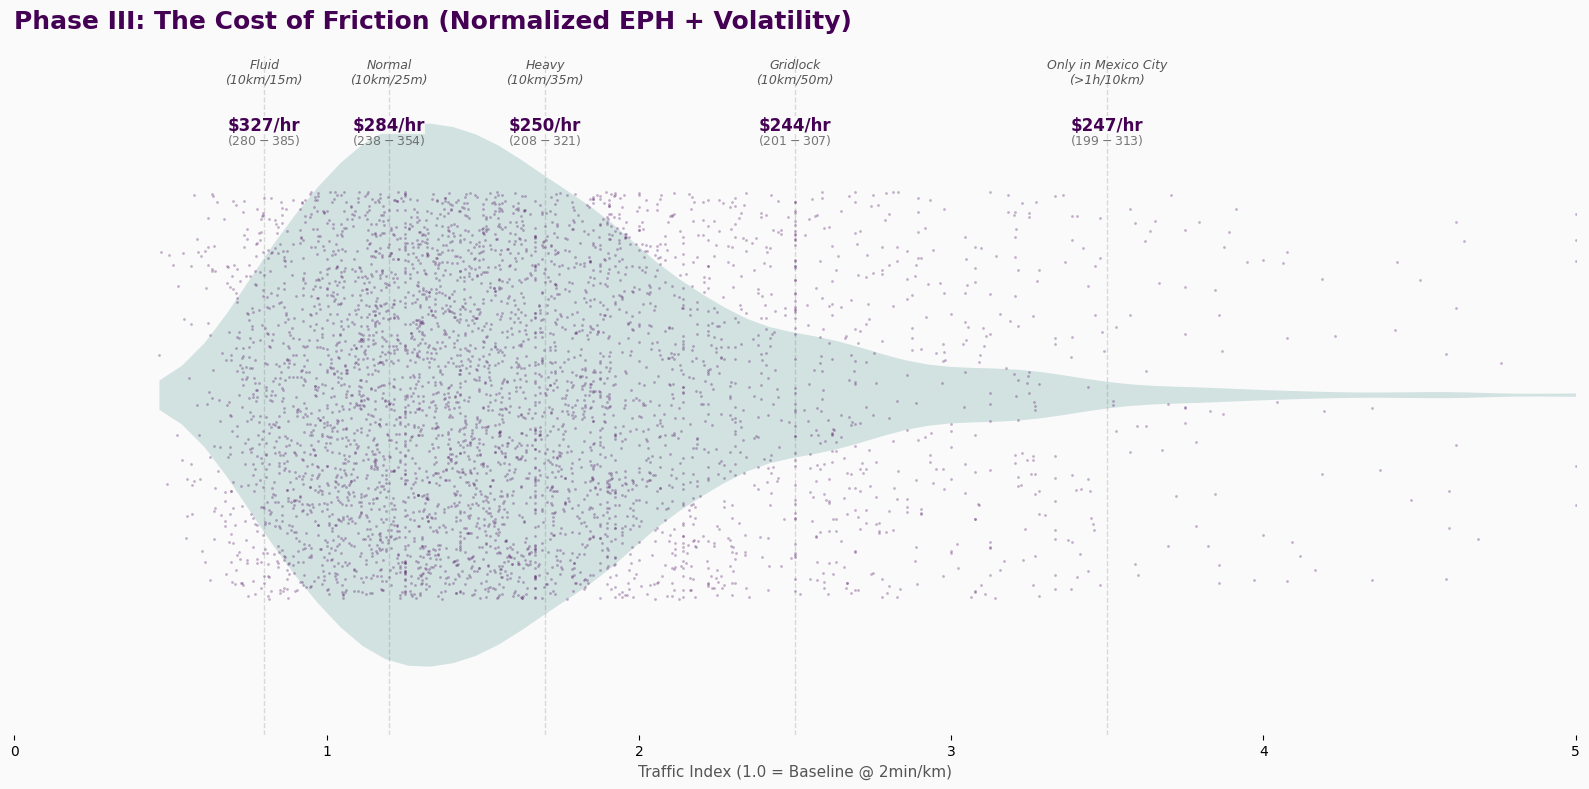

In [9]:
# ==============================================================================
# CELL 13 (FINAL GOLD): THE COST OF FRICTION + VOLATILITY (IQR)
# ==============================================================================
# Purpose: The ultimate truth of the marketplace.
#          Visualizes Median EPH (Efficiency) vs. Traffic Friction.
#          Adds IQR (Volatility) to show the "Risk Spread" in each zone.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA CANONICAL PALETTE
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_GRAY = "#555555"
PIENZA_BG = "#FAFAFA"

# 2. LOAD DATA
query = """
SELECT
    traffic_index_base_120,
    eph_direct
FROM v_offers_human
WHERE traffic_index_base_120 IS NOT NULL
  AND traffic_index_base_120 < 10
  AND eph_direct BETWEEN 0 AND 1000
"""
df_traffic = pd.read_sql(query, db_engine)

# 3. CALCULATE ROBUST STATS (MEDIAN + IQR)
bins = [0, 1.0, 1.5, 2.0, 3.0, 10]
labels = ['Fluid', 'Normal', 'Heavy', 'Gridlock', 'CDMX_Only']
df_traffic['traffic_bin'] = pd.cut(df_traffic['traffic_index_base_120'], bins=bins, labels=labels)

# Aggregation: Get Median, Q1 (25%), and Q3 (75%)
stats = df_traffic.groupby('traffic_bin', observed=True)['eph_direct'].agg(
    median='median',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).to_dict('index')

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(16, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# --- THE VIOLIN & STRIP ---
sns.violinplot(
    data=df_traffic, x='traffic_index_base_120', color=PIENZA_TEAL,
    inner=None, alpha=0.2, ax=ax, linewidth=0, cut=0
)
sns.stripplot(
    data=df_traffic, x='traffic_index_base_120',
    color=PIENZA_PURPLE, alpha=0.3, size=2, jitter=0.3, ax=ax, zorder=1
)

# 5. ANNOTATIONS: MEDIAN + IQR
anchors = [
    (0.8, "Fluid\n(10km/15m)", 'Fluid'),
    (1.2, "Normal\n(10km/25m)", 'Normal'),
    (1.7, "Heavy\n(10km/35m)", 'Heavy'),
    (2.5, "Gridlock\n(10km/50m)", 'Gridlock'),
    (3.5, "Only in Mexico City\n(>1h/10km)", 'CDMX_Only')
]

for x_val, label_text, bin_key in anchors:
    # Anchor Line
    ax.axvline(x_val, color=PIENZA_GRAY, alpha=0.2, linestyle='--', linewidth=1)

    # Context Label (Top)
    ax.text(x_val, ax.get_ylim()[1]*0.92, label_text,
            ha='center', fontsize=9, color=PIENZA_GRAY, style='italic')

    if bin_key in stats:
        # Extract stats
        med = stats[bin_key]['median']
        q1 = stats[bin_key]['q1']
        q3 = stats[bin_key]['q3']

        # 1. HERO METRIC: Median EPH
        ax.text(x_val, ax.get_ylim()[1]*0.78, f"${med:,.0f}/hr",
                ha='center', fontsize=12, weight='bold', color=PIENZA_PURPLE,
                bbox=dict(facecolor=PIENZA_BG, alpha=0.9, edgecolor='none', pad=0))

        # 2. SUB-METRIC: The IQR Range (Small & Discreet)
        # Formatted as "($Q1 - $Q3)" to show the spread
        ax.text(x_val, ax.get_ylim()[1]*0.74, f"(${q1:,.0f} - ${q3:,.0f})",
                ha='center', fontsize=9, color=PIENZA_GRAY, alpha=0.8)

# Styling
ax.set_title('Phase III: The Cost of Friction (Normalized EPH + Volatility)',
             fontsize=18, color=PIENZA_PURPLE, weight='bold', loc='left', pad=20)
ax.set_xlabel('Traffic Index (1.0 = Baseline @ 2min/km)', fontsize=11, color=PIENZA_GRAY)
ax.set_xlim(0, 5)

sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')

plt.tight_layout()
plt.show()

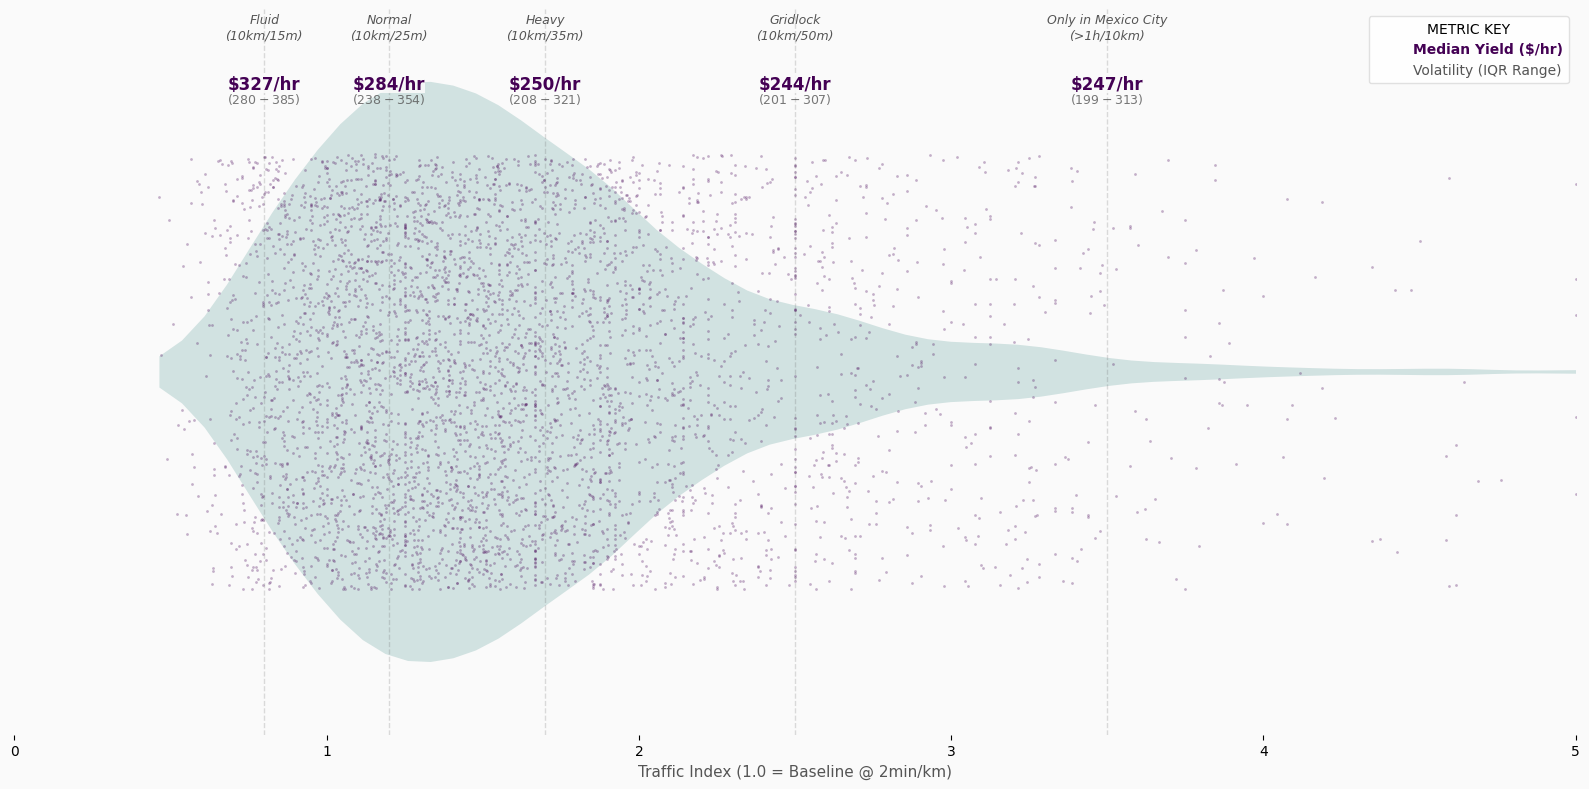

In [12]:
# ==============================================================================
# CELL 13 (FINAL GOLD + LEGEND): THE COST OF FRICTION & VOLATILITY
# ==============================================================================
# Purpose: The definitive visualization of EPH vs Traffic.
#          Includes Median (Efficiency), IQR (Volatility), and an explicit Legend.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. PIENZA CANONICAL PALETTE
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_GRAY = "#555555"
PIENZA_BG = "#FAFAFA"

# 2. LOAD DATA
query = """
SELECT
    traffic_index_base_120,
    eph_direct
FROM v_offers_human
WHERE traffic_index_base_120 IS NOT NULL
  AND traffic_index_base_120 < 10
  AND eph_direct BETWEEN 0 AND 1000
"""
df_traffic = pd.read_sql(query, db_engine)

# 3. CALCULATE ROBUST STATS
bins = [0, 1.0, 1.5, 2.0, 3.0, 10]
labels = ['Fluid', 'Normal', 'Heavy', 'Gridlock', 'CDMX_Only']
df_traffic['traffic_bin'] = pd.cut(df_traffic['traffic_index_base_120'], bins=bins, labels=labels)

stats = df_traffic.groupby('traffic_bin', observed=True)['eph_direct'].agg(
    median='median',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).to_dict('index')

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(16, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# --- VIOLIN & STRIP ---
sns.violinplot(
    data=df_traffic, x='traffic_index_base_120', color=PIENZA_TEAL,
    inner=None, alpha=0.2, ax=ax, linewidth=0, cut=0
)
sns.stripplot(
    data=df_traffic, x='traffic_index_base_120',
    color=PIENZA_PURPLE, alpha=0.3, size=2, jitter=0.3, ax=ax, zorder=1
)

# 5. ANNOTATIONS & LEGEND
anchors = [
    (0.8, "Fluid\n(10km/15m)", 'Fluid'),
    (1.2, "Normal\n(10km/25m)", 'Normal'),
    (1.7, "Heavy\n(10km/35m)", 'Heavy'),
    (2.5, "Gridlock\n(10km/50m)", 'Gridlock'),
    (3.5, "Only in Mexico City\n(>1h/10km)", 'CDMX_Only')
]

for x_val, label_text, bin_key in anchors:
    ax.axvline(x_val, color=PIENZA_GRAY, alpha=0.2, linestyle='--', linewidth=1)
    ax.text(x_val, ax.get_ylim()[1]*0.92, label_text, ha='center', fontsize=9, color=PIENZA_GRAY, style='italic')

    if bin_key in stats:
        med = stats[bin_key]['median']
        q1 = stats[bin_key]['q1']
        q3 = stats[bin_key]['q3']

        # HERO METRIC (Purple)
        ax.text(x_val, ax.get_ylim()[1]*0.78, f"${med:,.0f}/hr",
                ha='center', fontsize=12, weight='bold', color=PIENZA_PURPLE,
                bbox=dict(facecolor=PIENZA_BG, alpha=0.9, edgecolor='none', pad=0))

        # SUB-METRIC (Gray)
        ax.text(x_val, ax.get_ylim()[1]*0.74, f"(${q1:,.0f} - ${q3:,.0f})",
                ha='center', fontsize=9, color=PIENZA_GRAY, alpha=0.8)

# --- 6. EXPLICIT LEGEND ---
# We create a custom legend patch to explain the text hierarchy
import matplotlib.lines as mlines

# Create "dummy" handles for the legend
median_handle = mlines.Line2D([], [], color=PIENZA_PURPLE, marker='None',
                              linestyle='None', label='Median Yield ($/hr)')
iqr_handle = mlines.Line2D([], [], color=PIENZA_GRAY, marker='None',
                           linestyle='None', label='Volatility (IQR Range)')

# Add the legend to the upper right
leg = ax.legend(handles=[median_handle, iqr_handle], loc='upper right',
          frameon=True, fontsize=10, title="METRIC KEY")
leg.get_frame().set_edgecolor('#DDDDDD')
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.9)

# Color the text in the legend to match the data (Advanced Matplotlib trick)
plt.setp(leg.get_texts()[0], color=PIENZA_PURPLE, weight='bold')
plt.setp(leg.get_texts()[1], color=PIENZA_GRAY)


# Styling
ax.set_xlabel('Traffic Index (1.0 = Baseline @ 2min/km)', fontsize=11, color=PIENZA_GRAY)
ax.set_xlim(0, 5)
sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')

plt.tight_layout()
plt.show()